# Setup

In [102]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict


In [103]:
# Function to load in the files
def load_data(run):
    bike_frames = []
    drone_frames = []

    n_bikes = len(os.listdir(f"../logs/bike/run_{run}"))
    n_drones = len(os.listdir(f"../logs/drone/run_{run}"))

    name_dict = {}
    name = ""

    for i in range(1, n_bikes + 1):
        bike_file = f"../logs/bike/run_{run}/bike_{i}.csv"
        with open(bike_file, "r") as f:
            name = f.readline().strip()
            
        if os.path.exists(bike_file):
            bike_df = pd.read_csv(bike_file, header=1, skipinitialspace=True)
            bike_df.insert(loc=0, column="ID", value=i)
            bike_frames.append(bike_df)

    for i in range(1, n_drones + 1):
        drone_file = f"../logs/drone/run_{run}/drone_{i}.csv"
        if os.path.exists(drone_file):
            drone_df = pd.read_csv(drone_file, header=1, skipinitialspace=True)
            drone_df.insert(loc=0, column="ID", value=i)
            drone_frames.append(drone_df)

    bike_data = pd.concat(bike_frames, ignore_index=True) if bike_frames else pd.DataFrame()
    drone_data = pd.concat(drone_frames, ignore_index=True) if drone_frames else pd.DataFrame()

    name = name.split()
    for i, key in enumerate(name):
        if i % 2 == 0:
            name_dict[key] = name[i+1]

    bike_data.attrs["run_info"] = name_dict
    drone_data.attrs["run_info"] = name_dict
    
    return bike_data, drone_data

In [104]:
def parse_ids(value):
    return set(map(int, str(value).replace("[", "").replace("]", "").split()))

def add_nearby_info(bike_data, drone_data, radius):
    bike_data = bike_data.copy()
    drone_data = drone_data.copy()

    bike_data["nearby_drones"] = 0
    bike_data["min_distance"] = 0.0
    bike_data["in_camera_shot"] = False

    drone_data["nearby_bikes"] = 0
    drone_data["min_distance"] = 0.0
    drone_data["bikes_in_camera"] = 0

    bike_nearby_drones = np.zeros(len(bike_data), dtype=int)
    bike_min_distance = np.full(len(bike_data), np.inf)
    bike_in_camera = np.zeros(len(bike_data), dtype=bool)

    drone_nearby_bikes = np.zeros(len(drone_data), dtype=int)
    drone_min_distance = np.full(len(drone_data), np.inf)
    drone_bikes_in_camera = np.zeros(len(drone_data), dtype=int)

    bike_groups = bike_data.groupby("Timestep", sort=False).indices
    drone_groups = drone_data.groupby("Timestep", sort=False).indices

    bike_ids = bike_data["ID"].to_numpy()
    drone_bike_ids_raw = drone_data["Bikes-ID"].to_numpy()

    bike_pos = bike_data[["Pos x", "Pos y", "Pos z"]].to_numpy(dtype=float)
    drone_pos = drone_data[["Pos x", "Pos y", "Pos z"]].to_numpy(dtype=float)

    common_timesteps = set(bike_groups.keys()) & set(drone_groups.keys())

    for timestep in common_timesteps:
        b_idx = bike_groups[timestep]
        d_idx = drone_groups[timestep]

        b_positions = bike_pos[b_idx]
        d_positions = drone_pos[d_idx]

        diff = b_positions[:, None, :] - d_positions[None, :, :]

        nearby_cube = np.all(np.abs(diff) <= radius, axis=2)

        distances = np.sqrt(np.sum(diff ** 2, axis=2))

        bike_nearby_drones[b_idx] = nearby_cube.sum(axis=1)
        drone_nearby_bikes[d_idx] = nearby_cube.sum(axis=0)

        bike_min_distance[b_idx] = distances.min(axis=1)
        drone_min_distance[d_idx] = distances.min(axis=0)

        current_bike_ids = bike_ids[b_idx]

        for local_d_pos, global_d_idx in enumerate(d_idx):
            visible_ids = parse_ids(drone_bike_ids_raw[global_d_idx])

            visible_mask = np.isin(current_bike_ids, list(visible_ids))

            drone_bikes_in_camera[global_d_idx] = visible_mask.sum()

            bike_in_camera[b_idx[visible_mask]] = True

    bike_data["nearby_drones"] = bike_nearby_drones
    bike_data["min_distance"] = bike_min_distance
    bike_data["in_camera_shot"] = bike_in_camera

    drone_data["nearby_bikes"] = drone_nearby_bikes
    drone_data["min_distance"] = drone_min_distance
    drone_data["bikes_in_camera"] = drone_bikes_in_camera

    return bike_data, drone_data

In [105]:
def setup():
    run = len(os.listdir("../logs/bike"))

    all_bike_data = []
    all_drone_data = []

    for i in range(1, run + 1):
        bike_data, drone_data = load_data(i)
        run_info = bike_data.attrs["run_info"]

        bike_data, drone_data = add_nearby_info(
            bike_data,
            drone_data,
            int(run_info["Size:"])
        )

        bike_data.attrs["run_info"] = run_info
        drone_data.attrs["run_info"] = run_info

        all_bike_data.append(bike_data)
        all_drone_data.append(drone_data)

    return all_bike_data, all_drone_data

#### Change amount of drones and bikes below to fit the numbers on the run


In [106]:
bike_data_list, drone_data_list = [], []
bike_data_list, drone_data_list = setup()
runs = len(bike_data_list)


In [107]:
info_dict = defaultdict(lambda: defaultdict())

for i in range(1, runs+1):
    #Save to csv for later use
    bike_data_list[i-1].to_csv(f"data/bike/run_{i}.csv", index=False)
    drone_data_list[i-1].to_csv(f"data/drone/run_{i}.csv", index=False)

    info = bike_data_list[i-1].attrs["run_info"]
    info_dict[i]['bikes'] = info['Bikes:']
    info_dict[i]['drones'] = info['Drones:']
    info_dict[i]['stage'] = info['Stage:']


# Plot data

#### Average distance from drone to nearest bike

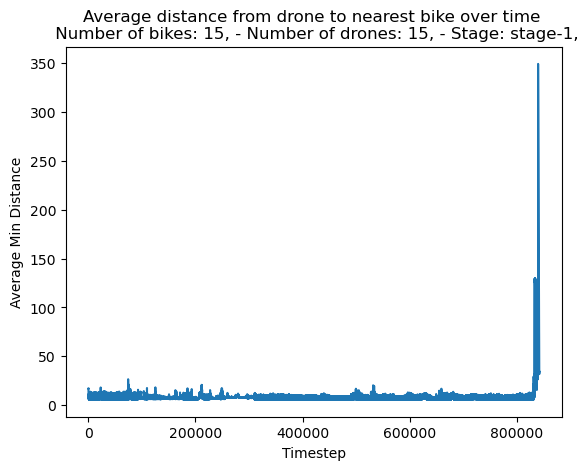

In [108]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/drone/run_{i}.csv")
    avg_dist = df.groupby("Timestep")["min_distance"].agg(["mean", "min", "max"]).reset_index()

    sns.lineplot(data=avg_dist, x="Timestep", y="mean")

    # plt.fill_between(
    #     avg_dist["Timestep"],
    #     avg_dist["min"],
    #     avg_dist["max"],
    #     alpha=0.4
    # )

    plt.title(f"Average distance from drone to nearest bike over time \n Number of bikes: {info_dict[i]['bikes']} - Number of drones: {info_dict[i]['drones']} - Stage: {info_dict[i]['stage']}")
    plt.xlabel("Timestep")
    plt.ylabel("Average Min Distance")
    plt.show()

#### Average distance from bike to nearest drone

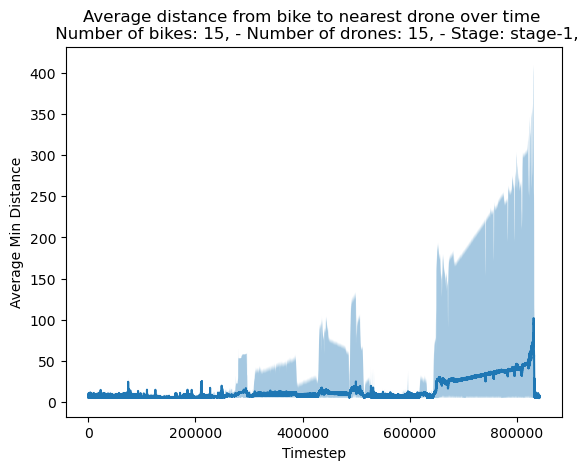

In [109]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/bike/run_{i}.csv")
    avg_dist = df.groupby("Timestep")["min_distance"].agg(["mean", "min", "max"]).reset_index()

    sns.lineplot(data=avg_dist, x="Timestep", y="mean")

    plt.fill_between(
        avg_dist["Timestep"],
        avg_dist["min"],
        avg_dist["max"],
        alpha=0.4
    )

    plt.title(f"Average distance from bike to nearest drone over time \n Number of bikes: {info_dict[i]['bikes']} - Number of drones: {info_dict[i]['drones']} - Stage: {info_dict[i]['stage']}")
    plt.xlabel("Timestep")
    plt.ylabel("Average Min Distance")
    plt.show()

### Percentage of bikes in range of a drone


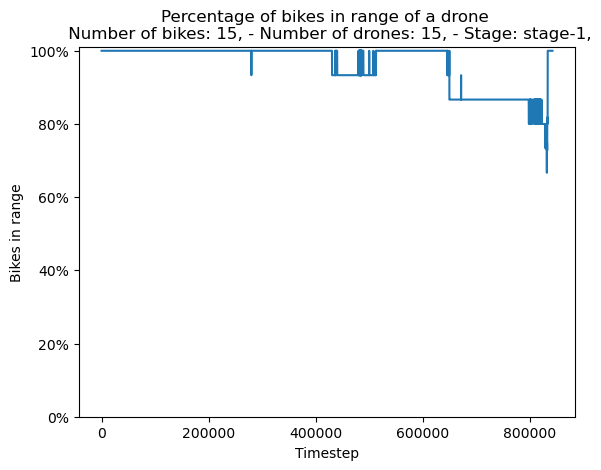

In [110]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/bike/run_{i}.csv")
    percentage_per_time = (
        df.groupby("Timestep")["nearby_drones"]
        .apply(lambda x: (x > 0).mean() * 100)
        .reset_index(name="bikes_in_range_of_drones")
    )

    sns.lineplot(data=percentage_per_time, x="Timestep", y="bikes_in_range_of_drones")
    plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
    plt.ylim(0, 101)
    plt.title(f"Percentage of bikes in range of a drone \n Number of bikes: {info_dict[i]['bikes']} - Number of drones: {info_dict[i]['drones']} - Stage: {info_dict[i]['stage']}")
    plt.ylabel("Bikes in range")
    plt.show()

### Percentage of bikes in camera shot of a drone

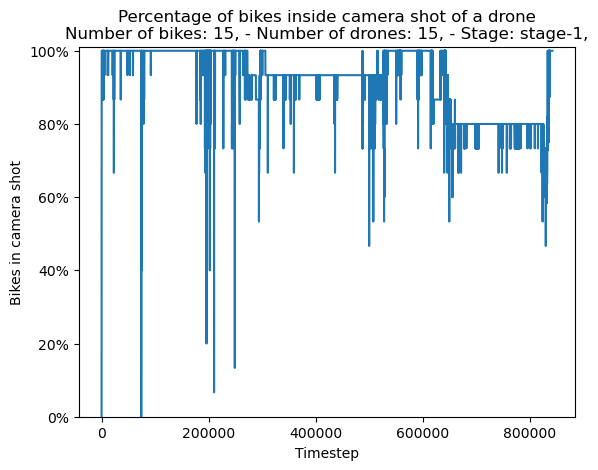

In [112]:
for i in range(1, runs + 1):
    df = pd.read_csv(f"data/bike/run_{i}.csv")

    df["in_camera_shot"] = df["in_camera_shot"].astype(str).str.lower() == "true"

    percentage_per_time = (
        df.groupby("Timestep")["in_camera_shot"]
        .mean()
        .mul(100)
        .reset_index(name="bikes_in_camera_shot")
    )

    sns.lineplot(
        data=percentage_per_time,
        x="Timestep",
        y="bikes_in_camera_shot"
    )

    plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
    plt.ylim(0, 101)
    plt.title(
        f"Percentage of bikes inside camera shot of a drone\n"
        f"Number of bikes: {info_dict[i]['bikes']} - "
        f"Number of drones: {info_dict[i]['drones']} - "
        f"Stage: {info_dict[i]['stage']}"
    )
    plt.ylabel("Bikes in camera shot")
    plt.show()

### Amount of bikes not within a camera each timestep

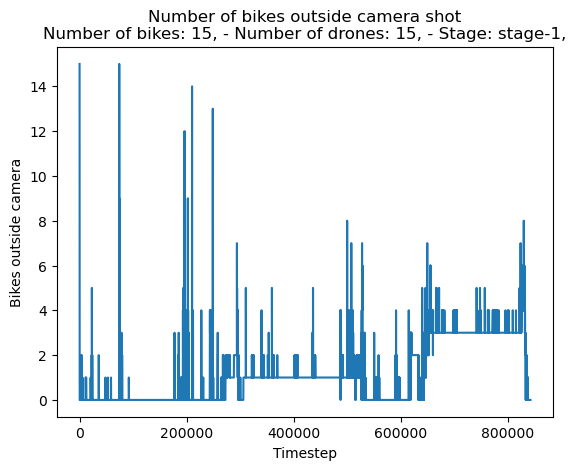

In [113]:
for i in range(1, runs + 1):
    df = pd.read_csv(f"data/bike/run_{i}.csv")

    df["in_camera_shot"] = df["in_camera_shot"].astype(str).str.lower() == "true"

    bikes_outside = (
        df.groupby("Timestep")["in_camera_shot"]
        .apply(lambda x: (~x).sum())
        .reset_index(name="bikes_outside_camera")
    )

    sns.lineplot(
        data=bikes_outside,
        x="Timestep",
        y="bikes_outside_camera"
    )

    plt.title(
        f"Number of bikes outside camera shot\n"
        f"Number of bikes: {info_dict[i]['bikes']} - "
        f"Number of drones: {info_dict[i]['drones']} - "
        f"Stage: {info_dict[i]['stage']}"
    )

    plt.ylabel("Bikes outside camera")
    plt.show()

### Collisions over time

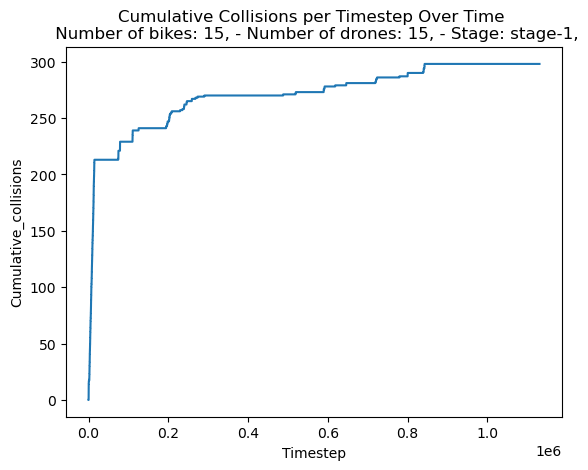

In [114]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/drone/run_{i}.csv")
    collisions_at_time = df.groupby("Timestep")["Collisions"].sum().reset_index()

    #Each drone in a collision detects it, so we divide by 2
    collisions_at_time["Collisions"] = collisions_at_time["Collisions"] / 2
    collisions_at_time["Cumulative_collisions"] = collisions_at_time["Collisions"].cumsum()

    sns.lineplot(
        data=collisions_at_time, x="Timestep", y="Cumulative_collisions"
    )

    plt.title(f"Cumulative Collisions per Timestep Over Time \n Number of bikes: {info_dict[i]['bikes']} - Number of drones: {info_dict[i]['drones']} - Stage: {info_dict[i]['stage']}")
    plt.show()


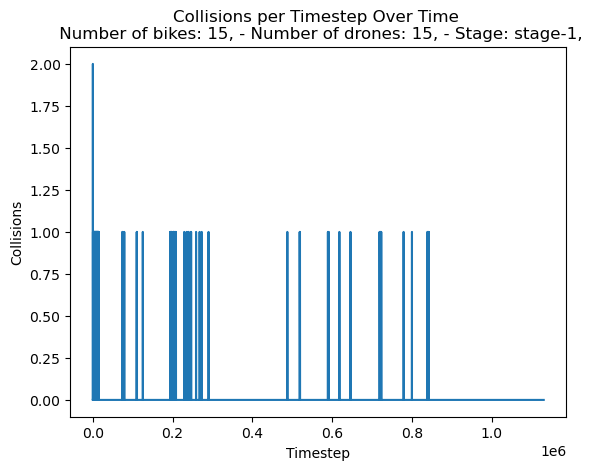

In [115]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/drone/run_{i}.csv")
    collisions_at_time = df.groupby("Timestep")["Collisions"].sum().reset_index()

    #Each drone in a collision detects it, so we divide by 2
    collisions_at_time["Collisions"] = collisions_at_time["Collisions"] / 2

    sns.lineplot(data=collisions_at_time, x="Timestep", y="Collisions")

    plt.title(f"Collisions per Timestep Over Time \n Number of bikes: {info_dict[i]['bikes']} - Number of drones: {info_dict[i]['drones']} - Stage: {info_dict[i]['stage']}")
    plt.show()

### Average amount of bikes in range of a drone over time

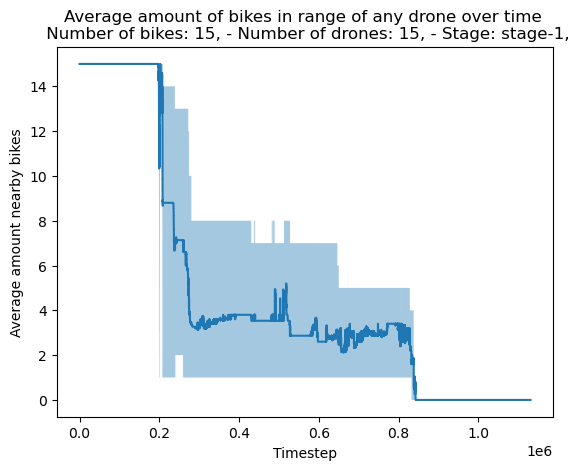

In [116]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/drone/run_{i}.csv")
    nearby_bikes_stats = df.groupby("Timestep")["nearby_bikes"].agg(["mean", "min", "max"]).reset_index()

    sns.lineplot(data=nearby_bikes_stats, x="Timestep", y="mean")

    plt.fill_between(
        nearby_bikes_stats["Timestep"],
        nearby_bikes_stats["min"],
        nearby_bikes_stats["max"],
        alpha=0.4
    )

    plt.title(f"Average amount of bikes in range of any drone over time \n Number of bikes: {info_dict[i]['bikes']} - Number of drones: {info_dict[i]['drones']} - Stage: {info_dict[i]['stage']}")
    plt.ylabel("Average amount nearby bikes")
    plt.show()

### Average amount of bikes inside camera shot of a drone

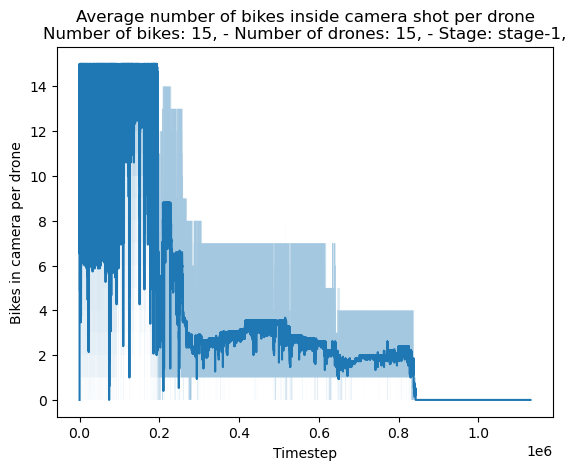

In [117]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/drone/run_{i}.csv")

    camera_stats = (
        df.groupby("Timestep")["bikes_in_camera"]
        .agg(["mean", "min", "max"])
        .reset_index()
    )

    sns.lineplot(data=camera_stats, x="Timestep", y="mean")

    plt.fill_between(
        camera_stats["Timestep"],
        camera_stats["min"],
        camera_stats["max"],
        alpha=0.4
    )

    plt.title(
        f"Average number of bikes inside camera shot per drone\n"
        f"Number of bikes: {info_dict[i]['bikes']} - "
        f"Number of drones: {info_dict[i]['drones']} - "
        f"Stage: {info_dict[i]['stage']}"
    )

    plt.ylabel("Bikes in camera per drone")
    plt.show()

### Amount of drones with no bikes in camera shot

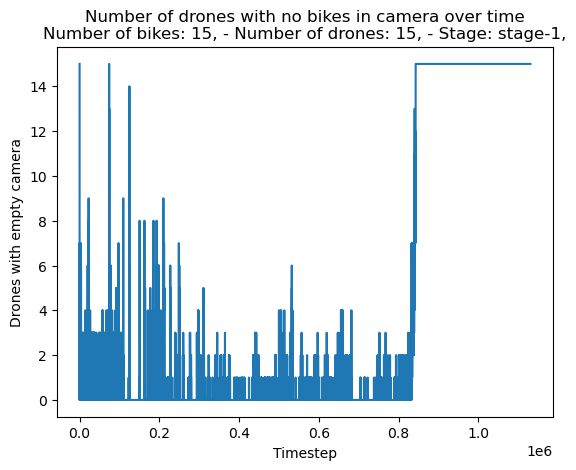

In [118]:
for i in range(1, runs+1):
    df = pd.read_csv(f"data/drone/run_{i}.csv")

    no_camera_stats = (
        df.groupby("Timestep")["bikes_in_camera"]
        .apply(lambda x: (x == 0).sum())
        .reset_index(name="drones_with_no_bikes_in_camera")
    )

    sns.lineplot(
        data=no_camera_stats,
        x="Timestep",
        y="drones_with_no_bikes_in_camera"
    )

    plt.title(
        f"Number of drones with no bikes in camera over time\n"
        f"Number of bikes: {info_dict[i]['bikes']} - "
        f"Number of drones: {info_dict[i]['drones']} - "
        f"Stage: {info_dict[i]['stage']}"
    )

    plt.ylabel("Drones with empty camera")
    plt.show()

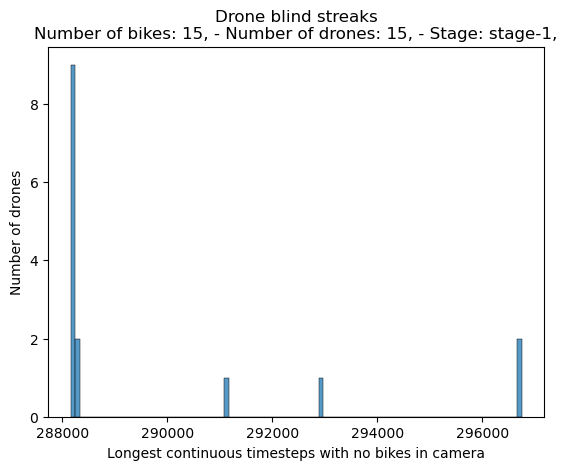

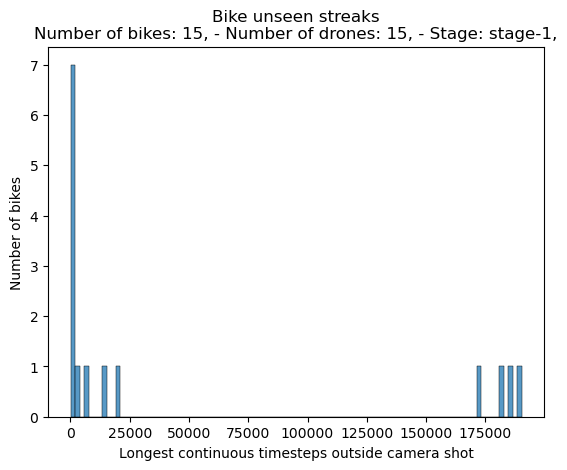

In [120]:
def longest_streak(boolean_series):
    max_streak = 0
    current = 0

    for val in boolean_series:
        if val:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0

    return max_streak


summary_rows = []

for i in range(1, runs + 1):

    drone_df = pd.read_csv(f"data/drone/run_{i}.csv")

    drone_streaks = []

    for drone_id, group in drone_df.groupby("ID"):
        group = group.sort_values("Timestep")

        no_bikes_in_camera = group["bikes_in_camera"] == 0

        streak = longest_streak(no_bikes_in_camera)
        drone_streaks.append(streak)

    max_drone_blind_streak = max(drone_streaks)
    avg_drone_blind_streak = sum(drone_streaks) / len(drone_streaks)


    bike_df = pd.read_csv(f"data/bike/run_{i}.csv")

    bike_df["in_camera_shot"] = (
        bike_df["in_camera_shot"]
        .astype(str)
        .str.lower()
        .eq("true")
    )

    bike_streaks = []

    for bike_id, group in bike_df.groupby("ID"):
        group = group.sort_values("Timestep")

        bike_not_seen = ~group["in_camera_shot"]

        streak = longest_streak(bike_not_seen)
        bike_streaks.append(streak)

    max_bike_unseen_streak = max(bike_streaks)
    avg_bike_unseen_streak = sum(bike_streaks) / len(bike_streaks)

    summary_rows.append({
        "run": i,
        "bikes": info_dict[i]["bikes"],
        "drones": info_dict[i]["drones"],
        "stage": info_dict[i]["stage"],
        "max_drone_blind_streak": max_drone_blind_streak,
        "avg_drone_blind_streak": avg_drone_blind_streak,
        "max_bike_unseen_streak": max_bike_unseen_streak,
        "avg_bike_unseen_streak": avg_bike_unseen_streak
    })

    sns.histplot(drone_streaks, bins=100)

    plt.title(
        f"Drone blind streaks\n"
        f"Number of bikes: {info_dict[i]['bikes']} - "
        f"Number of drones: {info_dict[i]['drones']} - "
        f"Stage: {info_dict[i]['stage']}"
    )
    plt.xlabel("Longest continuous timesteps with no bikes in camera")
    plt.ylabel("Number of drones")
    plt.show()

    sns.histplot(bike_streaks, bins=100)

    plt.title(
        f"Bike unseen streaks\n"
        f"Number of bikes: {info_dict[i]['bikes']} - "
        f"Number of drones: {info_dict[i]['drones']} - "
        f"Stage: {info_dict[i]['stage']}"
    )
    plt.xlabel("Longest continuous timesteps outside camera shot")
    plt.ylabel("Number of bikes")
    plt.show()
